# Chapter 11: Multiple Linear Regression for Prediction Assessment

**Name:** Waylan Abbott
**Section:** 2

---

## Assignment Overview

**Business Context**: You're a data analyst working for an online real estate platform. Your manager wants you to build a **predictive model** that can accurately estimate home sale prices for new property listings. Unlike your previous work (Chapters 9-10) which focused on **explanatory modeling**, this task requires a model that **generalizes well to unseen data** and makes accurate predictions.

**Learning Objectives**:
- Understand the difference between explanatory and predictive modeling
- Implement train/test splits to measure generalization
- Build predictive models using sklearn pipelines
- Evaluate models using out-of-sample metrics (MAE, RMSE)
- Detect and understand overfitting
- Compare train vs test performance

**Important Notes**:
- This assignment focuses on **Chapter 11 content only** (prediction and evaluation)
- You **WILL** split data into train/test sets (this is essential for prediction)
- The goal is **predictive accuracy**, not coefficient interpretation
- Use sklearn pipelines to prevent data leakage

---

## Dataset Information

**Source**: Ames Housing Dataset  
**Original Author**: Dean De Cock, Truman State University  
**Publication**: Journal of Statistics Education Volume 19, Number 3 (2011)  
**URL**: http://jse.amstat.org/v19n3/decock.html

**Citation**:  
De Cock, D. (2011) "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project," *Journal of Statistics Education*, Volume 19, Number 3.

**Description**:  
The Ames Housing dataset contains information about residential property sales in Ames, Iowa. The dataset includes various features describing homes such as lot size, building quality, number of rooms, and neighborhood characteristics.

**Target Variable**: `SalePrice` - the property's sale price in dollars (continuous variable)

**Data Dictionary** (Key Variables):
- **SalePrice**: Sale price of the property in dollars (target variable)
- **MSSubClass**: Building class (e.g., 20=1-STORY 1946 & NEWER ALL STYLES, 60=2-STORY 1946 & NEWER)
- **MSZoning**: General zoning classification (e.g., RL=Residential Low Density, RM=Residential Medium Density)
- **LotFrontage**: Linear feet of street connected to property
- **LotArea**: Lot size in square feet
- **Street**: Type of road access (Grvl=Gravel, Pave=Paved)
- **Alley**: Type of alley access (Grvl, Pave, or NA if no alley access)
- **LotShape**: General shape of property (Reg=Regular, IR1=Slightly irregular, etc.)
- **LandContour**: Flatness of the property (Lvl=Near Flat/Level, etc.)
- **Utilities**: Type of utilities available (AllPub=All public Utilities, etc.)
- **LotConfig**: Lot configuration (Inside, Corner, CulDSac, etc.)
- **LandSlope**: Slope of property (Gtl=Gentle slope, Mod=Moderate, Sev=Severe)
- **Neighborhood**: Physical locations within Ames city limits (e.g., CollgCr=College Creek, Veenker=Veenker)
- **Condition1**: Proximity to main road or railroad (Norm=Normal, Feedr=Adjacent to feeder street, etc.)
- **Condition2**: Proximity to main road or railroad (if more than one is present)
- **BldgType**: Type of dwelling (1Fam=Single-family Detached, 2FmCon=Two-family Conversion, etc.)
- **HouseStyle**: Style of dwelling (1Story, 2Story, 1.5Fin, etc.)
- **OverallQual**: Overall material and finish quality (1-10 scale, where 10=Very Excellent)
- **OverallCond**: Overall condition rating (1-10 scale, where 10=Very Excellent)
- **YearBuilt**: Original construction date
- **YearRemodAdd**: Remodel date (same as construction date if no remodeling or additions)
- **RoofStyle**: Type of roof (Gable, Hip, Flat, etc.)
- **RoofMatl**: Roof material (CompShg=Standard (Composite) Shingle, etc.)
- **Exterior1st**: Exterior covering on house (VinylSd, MetalSd, Wd Sdng, etc.)
- **Exterior2nd**: Exterior covering on house (if more than one material)
- **MasVnrType**: Masonry veneer type (BrkCmn, BrkFace, CBlock, None, Stone)
- **MasVnrArea**: Masonry veneer area in square feet
- **ExterQual**: Exterior material quality (Ex=Excellent, Gd=Good, TA=Typical/Average, etc.)
- **ExterCond**: Present condition of the material on the exterior (Ex, Gd, TA, etc.)
- **Foundation**: Type of foundation (BrkTil, CBlock, PConc, Slab, Stone, Wood)
- **BsmtQual**: Height of the basement (Ex, Gd, TA, Fa, Po, or NA if no basement)
- **BsmtCond**: General condition of the basement (Ex, Gd, TA, Fa, Po, or NA)
- **BsmtExposure**: Refers to walkout or garden level walls (Gd, Av, Mn, No, or NA)
- **BsmtFinType1**: Rating of basement finished area (GLQ=Good Living Quarters, ALQ=Average, etc.)
- **BsmtFinSF1**: Type 1 finished square feet
- **BsmtFinType2**: Rating of basement finished area (if multiple types)
- **BsmtFinSF2**: Type 2 finished square feet
- **BsmtUnfSF**: Unfinished square feet of basement area
- **TotalBsmtSF**: Total square feet of basement area
- **Heating**: Type of heating (GasA=Gas forced warm air, GasW=Gas hot water, etc.)
- **HeatingQC**: Heating quality and condition (Ex, Gd, TA, Fa, Po)
- **CentralAir**: Central air conditioning (N=No, Y=Yes)
- **Electrical**: Electrical system (SBrkr=Standard Circuit Breakers & Romex, etc.)
- **1stFlrSF**: First Floor square feet
- **2ndFlrSF**: Second floor square feet
- **LowQualFinSF**: Low quality finished square feet (all floors)
- **TotalSF**: Total square feet (sum of 1stFlrSF, 2ndFlrSF, and TotalBsmtSF)
- **BsmtFullBath**: Basement full bathrooms
- **BsmtHalfBath**: Basement half bathrooms
- **FullBath**: Full bathrooms above grade
- **HalfBath**: Half baths above grade
- **BedroomAbvGr**: Bedrooms above grade (does NOT include basement bedrooms)
- **KitchenAbvGr**: Kitchens above grade
- **KitchenQual**: Kitchen quality (Ex, Gd, TA, Fa, Po)
- **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms)
- **Functional**: Home functionality (Typ=Typical Functionality, Min1=Minor Deductions, etc.)
- **Fireplaces**: Number of fireplaces
- **FireplaceQu**: Fireplace quality (Ex, Gd, TA, Fa, Po, or NA if no fireplace)
- **GarageType**: Garage location (Attchd=Attached to home, Detchd=Detached, etc.)
- **GarageYrBlt**: Year garage was built
- **GarageFinish**: Interior finish of the garage (Fin=Finished, RFn=Rough Finished, Unf=Unfinished, NA=No Garage)
- **GarageCars**: Size of garage in car capacity
- **GarageArea**: Size of garage in square feet
- **GarageQual**: Garage quality (Ex, Gd, TA, Fa, Po, or NA)
- **GarageCond**: Garage condition (Ex, Gd, TA, Fa, Po, or NA)
- **PavedDrive**: Paved driveway (Y=Paved, P=Partial, N=Dirt/Gravel)
- **WoodDeckSF**: Wood deck area in square feet
- **OpenPorchSF**: Open porch area in square feet
- **EnclosedPorch**: Enclosed porch area in square feet
- **3SsnPorch**: Three season porch area in square feet
- **ScreenPorch**: Screen porch area in square feet
- **PoolArea**: Pool area in square feet
- **PoolQC**: Pool quality (Ex, Gd, TA, Fa, or NA if no pool)
- **Fence**: Fence quality (GdPrv=Good Privacy, MnPrv=Minimum Privacy, etc., or NA if no fence)
- **MiscFeature**: Miscellaneous feature not covered in other categories (Elev=Elevator, Gar2=2nd Garage, etc., or NA)
- **MiscVal**: $Value of miscellaneous feature
- **MoSold**: Month Sold (1-12)
- **YrSold**: Year Sold
- **SaleType**: Type of sale (WD=Warranty Deed, CWD=Warranty Deed - Cash, etc.)
- **SaleCondition**: Condition of sale (Normal, Abnorml=Abnormal, AdjLand=Adjoining Land Purchase, etc.)

**Note**: This is a subset of key variables. The full dataset contains 80 columns total, including many categorical variables that will be encoded during preprocessing.

---

# Part 1: Load and Prepare Data

In this section, you'll load the dataset and perform basic data cleaning. Note that for predictive modeling, we focus on preparing data that will generalize well to new observations.

## Question 1: Load and Clean the Dataset

Load the `housing.csv` file and perform basic data cleaning:
1. Remove rows with missing `SalePrice` values
2. Impute missing numeric values with median
3. Impute missing categorical values with mode
4. Separate label (`SalePrice`) and features

**Checkpoint Question**: After cleaning, how many rows remain in the dataset?

In [1]:
# Question 1: Load and clean the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Step 1: Load the data
df = pd.read_csv('housing.csv')
print(f"Original dataset shape: {df.shape}")

# Step 2: Remove rows with missing SalePrice
df = df.dropna(subset=['SalePrice'])
print(f"After dropping missing SalePrice: {df.shape}")

# Step 3: Impute missing numeric values with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Step 4: Impute missing categorical values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values remaining: {df.isnull().sum().sum()}")

# Step 5: Separate label and features
y = df['SalePrice']
X = df.drop('SalePrice', axis=1)

print(f"\nRows remaining after cleaning: {len(df)}")
print(f"Features (X) shape: {X.shape}")
print(f"Label (y) shape: {y.shape}")

Original dataset shape: (2919, 80)
After dropping missing SalePrice: (1460, 80)
Missing values remaining: 0

Rows remaining after cleaning: 1460
Features (X) shape: (1460, 79)
Label (y) shape: (1460,)


# Part 2: Train/Test Split

In this section, you'll split your data into training and testing sets. This is essential for predictive modeling to measure generalization and prevent overfitting.

## Question 2: Create Train/Test Split

Split your data into training and testing sets:
1. Use `train_test_split` from `sklearn.model_selection`
2. Use an 80/20 split (80% training, 20% testing)
3. Set `random_state=42` for reproducibility
4. Display the shapes of `X_train`, `X_test`, `y_train`, and `y_test`

**Important**: The test set must be held aside and only used for final evaluation. Never use test data for training or model selection!

**Checkpoint Question**: How many samples are in the training set? (This should be approximately 80% of your cleaned data)

In [2]:
# Question 2: Create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train/Test Split Results")
print("=" * 40)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nTraining set rows: {X_train.shape[0]}")
print(f"Test set rows:     {X_test.shape[0]}")
print(f"Training percentage: {X_train.shape[0] / len(X) * 100:.1f}%")
print(f"Test percentage:     {X_test.shape[0] / len(X) * 100:.1f}%")

Train/Test Split Results
X_train shape: (1168, 79)
X_test shape:  (292, 79)
y_train shape: (1168,)
y_test shape:  (292,)

Training set rows: 1168
Test set rows:     292
Training percentage: 80.0%
Test percentage:     20.0%


# Part 3: Build Preprocessing Pipeline

In this section, you'll create a preprocessing pipeline using sklearn. This ensures that preprocessing steps are learned from training data only and applied consistently to test data, preventing data leakage.

## Question 3: Identify Feature Types

Identify which features are numeric and which are categorical. Use the **training data only** to make this determination.

**Checkpoint Question**: How many categorical features are in your dataset? (Count only features in the original dataset, before encoding)

In [3]:
# Question 3: Identify feature types using training data only
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Feature Type Identification (from training data)")
print("=" * 50)
print(f"Number of numeric features:     {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")
print(f"Total features:                 {len(numeric_features) + len(categorical_features)}")
print(f"\nNumeric features: {numeric_features}")
print(f"\nCategorical features: {categorical_features}")

Feature Type Identification (from training data)
Number of numeric features:     36
Number of categorical features: 43
Total features:                 79

Numeric features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'TotalSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'Bsm

## Question 4: Create Preprocessing Pipeline

Create a preprocessing pipeline using sklearn:
1. For **numeric features**: Use `SimpleImputer` with `strategy='median'` and `StandardScaler`
2. For **categorical features**: Use `SimpleImputer` with `strategy='most_frequent'` and `OneHotEncoder` with `handle_unknown='ignore'`
3. Combine these using `ColumnTransformer`

**Important**: All preprocessing must be learned from training data only!

**Checkpoint Question**: After preprocessing, how many features (columns) are in the transformed training set? (This includes all dummy-coded categorical variables)

In [4]:
# Question 4: Create preprocessing pipeline
# Numeric pipeline: impute with median, then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit on training data and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing Pipeline Results")
print("=" * 50)
print(f"Original training features:     {X_train.shape[1]}")
print(f"Transformed training features:  {X_train_processed.shape[1]}")
print(f"Original test features:         {X_test.shape[1]}")
print(f"Transformed test features:      {X_test_processed.shape[1]}")
print(f"\nNumeric features (unchanged):   {len(numeric_features)}")
print(f"Categorical features (encoded): {len(categorical_features)} -> {X_train_processed.shape[1] - len(numeric_features)}")

Preprocessing Pipeline Results
Original training features:     79
Transformed training features:  285
Original test features:         79
Transformed test features:      285

Numeric features (unchanged):   36
Categorical features (encoded): 43 -> 249


# Part 4: Build Predictive Model

In this section, you'll build a predictive MLR model using sklearn's `LinearRegression` and evaluate its performance on both training and test sets.

## Question 5: Build Predictive Model

Build a multiple linear regression model for prediction:
1. Use `LinearRegression` from `sklearn.linear_model`
2. Fit the model on the **processed training data**
3. Make predictions on both training and test sets
4. Calculate R² for both training and test sets using `r2_score` from `sklearn.metrics`

**Checkpoint Question**: What is the R² value on the **test set**? Round your answer to 4 decimal places.

In [5]:
# Question 5: Build predictive model using a pipeline
# Create full pipeline: preprocessor + linear regression
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit on training data
model_pipeline.fit(X_train, y_train)

# Make predictions on both sets
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

# Calculate R² for both sets
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Model Performance (R²)")
print("=" * 40)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")

Model Performance (R²)
Training R²: 0.9359
Test R²:     0.8861


## Question 6: Calculate Prediction Error Metrics

Calculate prediction error metrics for both training and test sets:
1. **Mean Absolute Error (MAE)**: Use `mean_absolute_error` from `sklearn.metrics`
2. **Root Mean Squared Error (RMSE)**: Calculate using `mean_squared_error` and taking the square root
3. Display metrics for both training and test sets

**Checkpoint Question**: What is the RMSE on the **test set**? Round your answer to 2 decimal places.

In [6]:
# Question 6: Calculate prediction error metrics
# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Prediction Error Metrics")
print("=" * 50)
print(f"{'Metric':<10} {'Training':>15} {'Test':>15}")
print("-" * 50)
print(f"{'MAE':<10} ${train_mae:>14,.2f} ${test_mae:>14,.2f}")
print(f"{'RMSE':<10} ${train_rmse:>14,.2f} ${test_rmse:>14,.2f}")

Prediction Error Metrics
Metric            Training            Test
--------------------------------------------------
MAE        $     12,698.61 $     18,266.81
RMSE       $     19,553.44 $     29,556.54


# Part 5: Evaluate Generalization and Overfitting

In this section, you'll compare training and test performance to assess whether your model generalizes well or is overfitting.

## Question 7: Compare Train vs Test Performance

Compare the model's performance on training vs test data:
1. Calculate the difference in R² between training and test sets
2. Calculate the difference in RMSE between test and training sets
3. Determine if there are signs of overfitting

**Overfitting indicators**:
- Test RMSE is significantly higher than training RMSE (>10% difference)
- Test R² is significantly lower than training R²

**Checkpoint Question**: What is the difference between test RMSE and training RMSE? (Test RMSE - Training RMSE). Round your answer to 2 decimal places.

In [7]:
# Question 7: Compare train vs test performance
r2_diff = train_r2 - test_r2
rmse_diff = test_rmse - train_rmse
rmse_pct_diff = ((test_rmse - train_rmse) / train_rmse) * 100

print("Train vs Test Performance Comparison")
print("=" * 50)
print(f"Training R²:  {train_r2:.4f}")
print(f"Test R²:      {test_r2:.4f}")
print(f"R² difference (Train - Test): {r2_diff:.4f}")
print()
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE:     ${test_rmse:,.2f}")
print(f"RMSE difference (Test - Train): ${rmse_diff:,.2f}")
print(f"RMSE % difference: {rmse_pct_diff:.2f}%")
print()
print("Overfitting Assessment:")
if rmse_pct_diff > 10:
    print(f"YES - Signs of overfitting detected.")
    print(f"Test RMSE is {rmse_pct_diff:.1f}% higher than training RMSE (threshold: >10%).")
    print(f"Test R² ({test_r2:.4f}) is substantially lower than training R² ({train_r2:.4f}).")
    print("The model has learned training-specific patterns that don't generalize well.")
else:
    print(f"NO - No strong signs of overfitting.")
    print(f"Test RMSE is only {rmse_pct_diff:.1f}% higher than training RMSE.")

Train vs Test Performance Comparison
Training R²:  0.9359
Test R²:      0.8861
R² difference (Train - Test): 0.0498

Training RMSE: $19,553.44
Test RMSE:     $29,556.54
RMSE difference (Test - Train): $10,003.10
RMSE % difference: 51.16%

Overfitting Assessment:
YES - Signs of overfitting detected.
Test RMSE is 51.2% higher than training RMSE (threshold: >10%).
Test R² (0.8861) is substantially lower than training R² (0.9359).
The model has learned training-specific patterns that don't generalize well.


## Question 8: Visualize Predictions vs Actual Values

Create scatter plots comparing predicted vs actual values for both training and test sets:
1. Create a figure with 2 subplots (side by side)
2. Left plot: Training set predictions vs actual values
3. Right plot: Test set predictions vs actual values
4. Add a diagonal reference line (y=x) to each plot
5. Add appropriate labels and titles

**Checkpoint Question**: What is the correlation between predicted and actual values on the **test set**? Round your answer to 4 decimal places. (Use `np.corrcoef()` or `pd.Series.corr()`)

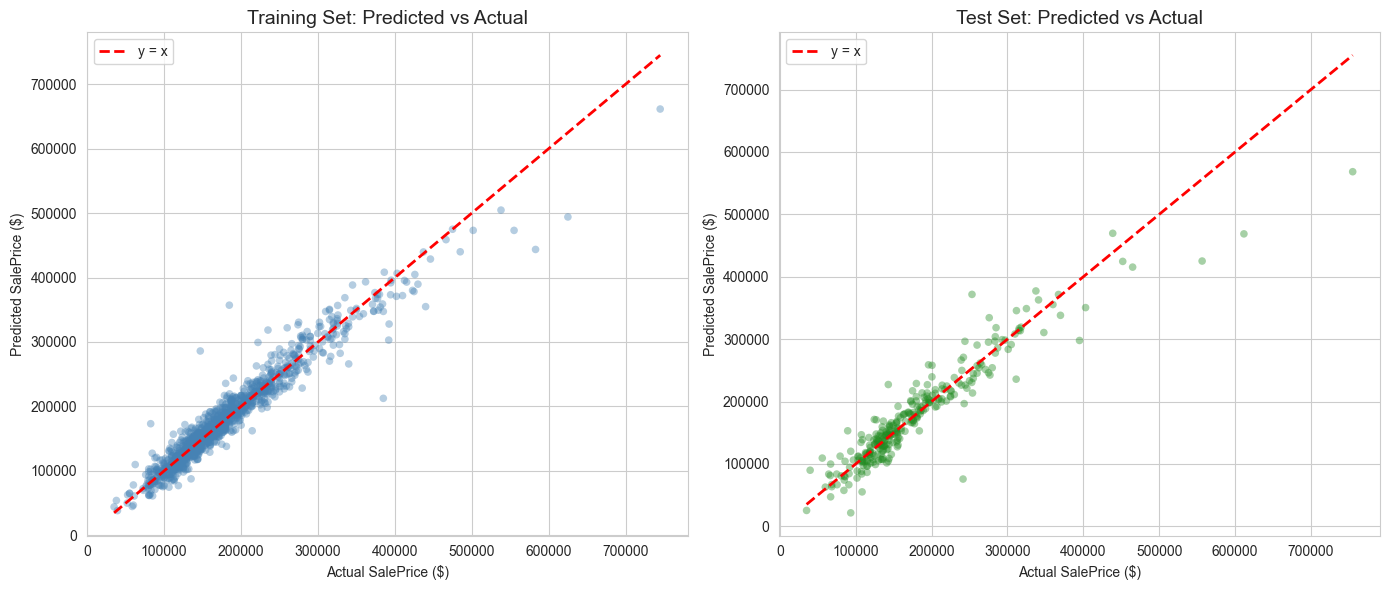

Correlation between predicted and actual (training): 0.9674
Correlation between predicted and actual (test):     0.9416


In [8]:
# Question 8: Scatter plots of predicted vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.4, color='steelblue', edgecolor='none', s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2, label='y = x')
axes[0].set_title('Training Set: Predicted vs Actual', fontsize=14)
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].legend()

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.4, color='forestgreen', edgecolor='none', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='y = x')
axes[1].set_title('Test Set: Predicted vs Actual', fontsize=14)
axes[1].set_xlabel('Actual SalePrice ($)')
axes[1].set_ylabel('Predicted SalePrice ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate correlation on test set
test_corr = np.corrcoef(y_test, y_test_pred)[0, 1]
train_corr = np.corrcoef(y_train, y_train_pred)[0, 1]

print(f"Correlation between predicted and actual (training): {train_corr:.4f}")
print(f"Correlation between predicted and actual (test):     {test_corr:.4f}")

# Part 6: Greedy Backward Feature Removal

In this section, you'll implement greedy backward feature removal to systematically reduce model complexity and improve generalization. This technique removes features one at a time based on validation-set performance, helping identify which features are most important for prediction.


## Question 9: Implement Greedy Backward Feature Removal

Greedy backward feature removal is a systematic approach to feature selection that removes one feature at a time, choosing the feature whose removal produces the best validation-set performance at each step.

**Task**:
1. Create a validation split from your training data (`X_train`, `y_train`) using `train_test_split` with `test_size=0.25` and `random_state=42`. This gives you a training subset and validation subset for feature selection.
2. Create helper functions:
   - `make_model(selected_features)`: Builds a preprocessing pipeline and model for a given set of features
   - `fit_and_score(selected_features)`: Fits a model on the training subset and returns MAE and RMSE on the validation subset
3. Implement the greedy backward removal loop:
   - Start with all features
   - At each step, try removing each remaining feature and choose the one that produces the lowest validation RMSE
   - Record the step number, removed feature, number of features remaining, validation MAE, and validation RMSE
   - Continue until only 5 features remain (to limit computation time)
4. Store results in a DataFrame called `removal_trace` with columns: `step`, `removed_feature`, `n_features`, `val_mae`, `val_rmse`

**Important**: Use the same preprocessing approach (numeric and categorical pipelines) that you used in Question 4. The validation set is used only for feature selection decisions, not for final model evaluation.

**Checkpoint Question**: What was the third feature removed using the greedy backward feature removal technique?

In [9]:
# Question 9: Greedy backward feature removal

# Step 1: Create validation split from training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)
print(f"Training subset: {X_train_sub.shape}")
print(f"Validation subset: {X_val.shape}")

# Step 2: Helper functions
def make_model(selected_features):
    """Build a preprocessing pipeline and model for a given set of features."""
    num_feats = [f for f in selected_features if f in numeric_features]
    cat_feats = [f for f in selected_features if f in categorical_features]
    
    transformers = []
    if num_feats:
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', num_pipe, num_feats))
    if cat_feats:
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ])
        transformers.append(('cat', cat_pipe, cat_feats))
    
    pre = ColumnTransformer(transformers)
    pipe = Pipeline([('preprocessor', pre), ('regressor', LinearRegression())])
    return pipe

def fit_and_score(selected_features):
    """Fit a model on training subset and return MAE and RMSE on validation subset."""
    pipe = make_model(selected_features)
    pipe.fit(X_train_sub[selected_features], y_train_sub)
    preds = pipe.predict(X_val[selected_features])
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return mae, rmse

# Step 3: Greedy backward removal loop
all_features = list(X_train.columns)
current_features = all_features.copy()
removal_trace = []

step = 0
while len(current_features) > 5:
    step += 1
    best_rmse = np.inf
    best_feature_to_remove = None
    best_mae = None
    
    for feat in current_features:
        candidate = [f for f in current_features if f != feat]
        mae, rmse = fit_and_score(candidate)
        if rmse < best_rmse:
            best_rmse = rmse
            best_mae = mae
            best_feature_to_remove = feat
    
    current_features.remove(best_feature_to_remove)
    removal_trace.append({
        'step': step,
        'removed_feature': best_feature_to_remove,
        'n_features': len(current_features),
        'val_mae': best_mae,
        'val_rmse': best_rmse
    })
    
    if step <= 5 or step % 10 == 0:
        print(f"Step {step}: Removed '{best_feature_to_remove}' | "
              f"Features remaining: {len(current_features)} | "
              f"Val RMSE: ${best_rmse:,.2f}")

# Step 4: Store results in DataFrame
removal_trace = pd.DataFrame(removal_trace)
print(f"\nTotal steps: {len(removal_trace)}")
print(f"\nFirst 5 features removed:")
print(removal_trace.head().to_string(index=False))
print(f"\nThird feature removed: {removal_trace.iloc[2]['removed_feature']}")

Training subset: (876, 79)
Validation subset: (292, 79)


Step 1: Removed 'Neighborhood' | Features remaining: 78 | Val RMSE: $28,550.44


Step 2: Removed 'RoofStyle' | Features remaining: 77 | Val RMSE: $27,779.64


Step 3: Removed 'GarageQual' | Features remaining: 76 | Val RMSE: $27,171.23


Step 4: Removed 'TotRmsAbvGrd' | Features remaining: 75 | Val RMSE: $26,608.35


...

Step 50: Removed 'ExterCond' | Features remaining: 29 | Val RMSE: $24,135.81


Step 60: Removed 'Exterior1st' | Features remaining: 19 | Val RMSE: $25,316.71


Step 70: Removed 'MasVnrArea' | Features remaining: 9 | Val RMSE: $29,029.15



Total steps: 74

First 5 features removed:


 step removed_feature  n_features      val_mae     val_rmse
    1    Neighborhood          78 19177.083982 28550.438689
    2       RoofStyle          77 18831.335962 27779.642377
    3      GarageQual          76 18365.829884 27171.231053
    4    TotRmsAbvGrd          75 17944.664716 26608.346007
    5      HouseStyle          74 17620.062441 26260.024410

Third feature removed: GarageQual


## Question 10: Visualize Feature Removal Results and Select Optimal Model

Now that you have the removal trace, visualize the results and select an optimal stopping point based on validation-set performance.

**Task**:
1. Create a line plot showing validation RMSE vs. number of features (x-axis: `n_features`, y-axis: `val_rmse`)
2. Add labels or annotations showing which feature was removed at key steps (e.g., every 10 steps or at the minimum RMSE point)
3. Identify the optimal number of features (the point with the lowest validation RMSE)
4. Extract the features that remain at the optimal point
5. Rebuild your model using only these optimal features on the full training set (`X_train`, `y_train`)
6. Evaluate this optimized model on the test set and compare to your original model

**Important**: The optimal point is where validation RMSE is minimized. After this point, removing more features increases error, indicating those features were important for prediction.

**Checkpoint Question**: What is the optimal number of features (the number of features at the step with the lowest validation RMSE)?

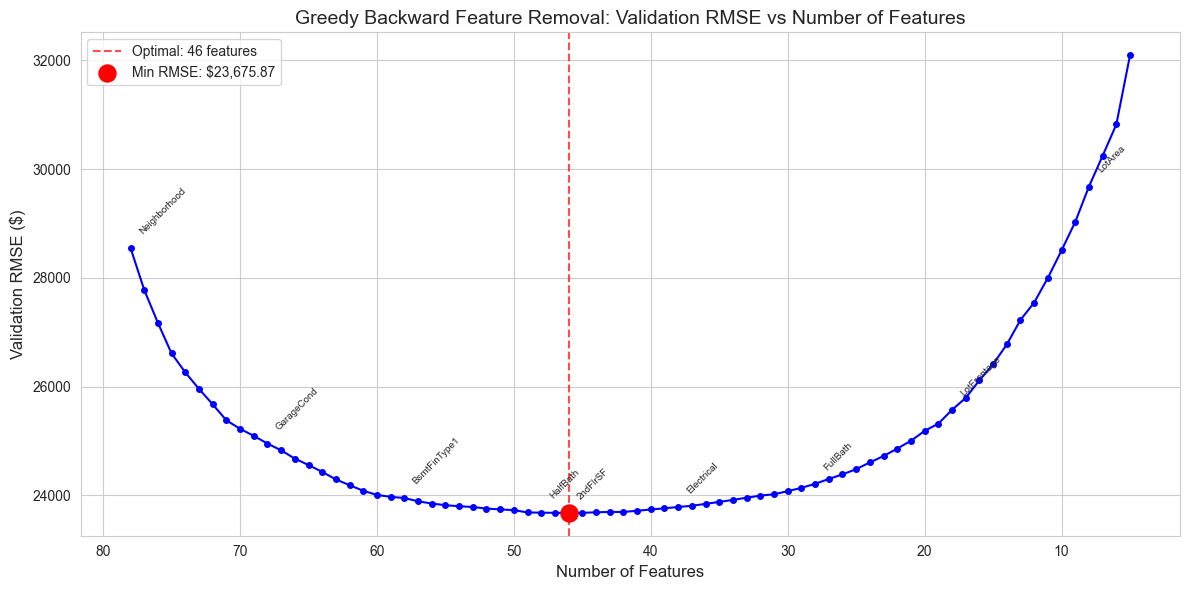

Optimal number of features: 46
Optimal validation RMSE: $23,675.87

Features removed (33): ['Neighborhood', 'RoofStyle', 'GarageQual', 'TotRmsAbvGrd', 'HouseStyle', 'GarageArea', 'GarageCars', 'LandContour', 'FireplaceQu', 'PoolQC', 'GarageCond', 'LandSlope', 'BsmtQual', 'MoSold', 'SaleType', 'PoolArea', 'Street', 'OpenPorchSF', 'GarageYrBlt', 'Fireplaces', 'BsmtFinType1', 'MiscFeature', 'LotShape', 'PavedDrive', 'YrSold', 'YearRemodAdd', 'GarageFinish', 'EnclosedPorch', 'MiscVal', 'BsmtCond', 'HalfBath', 'CentralAir', '2ndFlrSF']
Optimal features (46): ['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Alley', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'OverallQual', 'OverallCond', 'YearBuilt', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'Electrical', '1stFlrSF', 'LowQualFinSF', 'Tota


Optimal Model vs Original Model Comparison
Metric          Original (All)       Optimal (46 feat)   
------------------------------------------------------------
Train R²        0.9359               0.9087              
Test R²         0.8861               0.8747              
Train RMSE      $19,553.44           $23,330.04          
Test RMSE       $29,556.54           $31,000.23          


In [10]:
# Question 10: Visualize feature removal results and select optimal model

# Step 1: Line plot of validation RMSE vs number of features
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(removal_trace['n_features'], removal_trace['val_rmse'], 'b-o', markersize=4)

# Step 2: Find optimal point (minimum validation RMSE)
optimal_idx = removal_trace['val_rmse'].idxmin()
optimal_row = removal_trace.loc[optimal_idx]
optimal_n_features = int(optimal_row['n_features'])

ax.axvline(x=optimal_n_features, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_n_features} features')
ax.scatter(optimal_n_features, optimal_row['val_rmse'], color='red', s=150, zorder=5, label=f'Min RMSE: ${optimal_row["val_rmse"]:,.2f}')

# Annotate every 10 steps
for i, row in removal_trace.iterrows():
    if i % 10 == 0 or i == optimal_idx:
        ax.annotate(row['removed_feature'], 
                    xy=(row['n_features'], row['val_rmse']),
                    xytext=(5, 10), textcoords='offset points', fontsize=7, rotation=45)

ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Validation RMSE ($)', fontsize=12)
ax.set_title('Greedy Backward Feature Removal: Validation RMSE vs Number of Features', fontsize=14)
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

# Step 3: Identify optimal features
print(f"Optimal number of features: {optimal_n_features}")
print(f"Optimal validation RMSE: ${optimal_row['val_rmse']:,.2f}")

# Step 4: Extract features at optimal point
# Features remaining = all features minus those removed up to (and including) the optimal step
features_removed = removal_trace.loc[:optimal_idx, 'removed_feature'].tolist()
optimal_features = [f for f in all_features if f not in features_removed]
print(f"\nFeatures removed ({len(features_removed)}): {features_removed}")
print(f"Optimal features ({len(optimal_features)}): {optimal_features}")

# Step 5: Rebuild model with optimal features on full training set
optimal_model = make_model(optimal_features)
optimal_model.fit(X_train[optimal_features], y_train)

# Step 6: Evaluate on both sets
optimal_train_pred = optimal_model.predict(X_train[optimal_features])
optimal_test_pred = optimal_model.predict(X_test[optimal_features])

optimal_train_r2 = r2_score(y_train, optimal_train_pred)
optimal_test_r2 = r2_score(y_test, optimal_test_pred)
optimal_train_mae = mean_absolute_error(y_train, optimal_train_pred)
optimal_test_mae = mean_absolute_error(y_test, optimal_test_pred)
optimal_train_rmse = np.sqrt(mean_squared_error(y_train, optimal_train_pred))
optimal_test_rmse = np.sqrt(mean_squared_error(y_test, optimal_test_pred))

print(f"\nOptimal Model vs Original Model Comparison")
print("=" * 60)
print(f"{'Metric':<15} {'Original (All)':<20} {'Optimal ({} feat)':<20}".format(optimal_n_features))
print("-" * 60)
print(f"{'Train R²':<15} {train_r2:<20.4f} {optimal_train_r2:<20.4f}")
print(f"{'Test R²':<15} {test_r2:<20.4f} {optimal_test_r2:<20.4f}")
print(f"{'Train RMSE':<15} ${train_rmse:<19,.2f} ${optimal_train_rmse:<19,.2f}")
print(f"{'Test RMSE':<15} ${test_rmse:<19,.2f} ${optimal_test_rmse:<19,.2f}")

# Part 7: Model Comparison and Interpretation

In this section, you'll compare your model to baseline predictions and create summary tables of model performance.


## Question 11: Compare to Baseline Model

Now that you have your optimal model (with 45 features selected in Question 10), compare it to a simple baseline model:

Create a simple baseline model that always predicts the mean of the training set:
1. Calculate the mean of `y_train`
2. Create predictions for test set using this mean (all predictions are the same value)
3. Calculate RMSE for this baseline model on the test set
4. Compare baseline RMSE to your **optimal model's** test RMSE (from Question 10)

**Important**: Use the optimal model metrics (`optimal_test_rmse`) from Question 10, not the original model with all features.

**Checkpoint Question**: What is the percentage reduction in RMSE from the baseline model to the optimal model? Round your answer to 2 decimal places. (Calculate: ((baseline_rmse - optimal_test_rmse) / baseline_rmse) * 100)

In [11]:
# Question 11: Compare to baseline model

# Step 1: Calculate mean of training set
baseline_pred_value = y_train.mean()
print(f"Baseline prediction (mean of y_train): ${baseline_pred_value:,.2f}")

# Step 2: Create baseline predictions for test set
baseline_preds = np.full(len(y_test), baseline_pred_value)

# Step 3: Calculate baseline RMSE on test set
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print(f"Baseline RMSE on test set: ${baseline_rmse:,.2f}")

# Step 4: Compare to optimal model
print(f"Optimal model RMSE on test set: ${optimal_test_rmse:,.2f}")

pct_reduction = ((baseline_rmse - optimal_test_rmse) / baseline_rmse) * 100
print(f"\nPercentage reduction in RMSE: {pct_reduction:.2f}%")
print(f"\nThe optimal model reduces prediction error by {pct_reduction:.2f}% compared to")
print(f"simply predicting the mean sale price for every home.")

Baseline prediction (mean of y_train): $181,441.54
Baseline RMSE on test set: $87,619.03
Optimal model RMSE on test set: $31,000.23

Percentage reduction in RMSE: 64.62%

The optimal model reduces prediction error by 64.62% compared to
simply predicting the mean sale price for every home.


## Question 12: Create Performance Summary Table

Create a summary table comparing training and test performance for your **optimal model** (selected in Question 10):
1. Create a DataFrame with metrics for both training and test sets
2. Include R², MAE, and RMSE for each set
3. Use the optimal model metrics from Question 10 (`optimal_train_r2`, `optimal_test_r2`, `optimal_train_mae`, `optimal_test_mae`, `optimal_train_rmse`, `optimal_test_rmse`)
4. Display the table

**Important**: This summary table should reflect the performance of the optimal model with 45 features, not the original model with all features.

**Checkpoint Question**: What is the MAE on the **test set** for the optimal model? Round your answer to 2 decimal places.

In [12]:
# Question 12: Create performance summary table for optimal model
summary = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Training': [
        f"{optimal_train_r2:.4f}",
        f"${optimal_train_mae:,.2f}",
        f"${optimal_train_rmse:,.2f}"
    ],
    'Test': [
        f"{optimal_test_r2:.4f}",
        f"${optimal_test_mae:,.2f}",
        f"${optimal_test_rmse:,.2f}"
    ]
})

print(f"Optimal Model Performance Summary ({optimal_n_features} features)")
print("=" * 50)
print(summary.to_string(index=False))
print(f"\nTest MAE: ${optimal_test_mae:,.2f}")

Optimal Model Performance Summary (46 features)
Metric   Training       Test
    R²     0.9087     0.8747
   MAE $15,391.20 $19,647.86
  RMSE $23,330.04 $31,000.23

Test MAE: $19,647.86


## Question 13: Make a Prediction for a New Case

Now that you have your optimal model (with 45 features selected in Question 10), you can use it to make predictions for new, unseen cases. This is the practical application of your predictive model.

**Task**:
1. Create a new case (one-row DataFrame) for a hypothetical home by copying the first row from `X_test` as a template
2. Modify several key features to create a new scenario:
   - Set `LotArea` to 8000
   - Set `YearBuilt` to 2010
   - Set `BedroomAbvGr` to 4
   - Set `OverallQual` to 7
   - Set `TotalBsmtSF` to 1200
   - Set `1stFlrSF` to 1500
   - Set `FullBath` to 2
3. Use your **optimal model** (`optimal_model` from Question 10) to make a prediction
4. Display the predicted sale price (rounded to 2 decimal places)

**Important**: The optimal model is a Pipeline that includes preprocessing, so you can pass the raw new case DataFrame (with only the optimal features) directly to `optimal_model.predict()`. The pipeline will automatically handle all preprocessing (imputation, scaling, encoding) that was applied during training.

**Checkpoint Question**: What is the predicted sale price for this new case? Round your answer to the nearest dollar (no decimal places).

In [13]:
# Question 13: Make a prediction for a new case

# Step 1: Create new case from first row of X_test as template
new_case = X_test.iloc[[0]].copy()

# Step 2: Modify key features
new_case['LotArea'] = 8000
new_case['YearBuilt'] = 2010
new_case['BedroomAbvGr'] = 4
new_case['OverallQual'] = 7
new_case['TotalBsmtSF'] = 1200
new_case['1stFlrSF'] = 1500
new_case['FullBath'] = 2

# Step 3: Use optimal model to predict (filter to optimal features only)
predicted_price = optimal_model.predict(new_case[optimal_features])

# Step 4: Display the result
print("New Case Features (modified):")
print(f"  LotArea:      8,000 sq ft")
print(f"  YearBuilt:    2010")
print(f"  BedroomAbvGr: 4")
print(f"  OverallQual:  7")
print(f"  TotalBsmtSF:  1,200 sq ft")
print(f"  1stFlrSF:     1,500 sq ft")
print(f"  FullBath:     2")
print(f"\nPredicted Sale Price: ${predicted_price[0]:,.2f}")
print(f"Predicted Sale Price (rounded to nearest dollar): ${predicted_price[0]:,.0f}")

New Case Features (modified):
  LotArea:      8,000 sq ft
  YearBuilt:    2010
  BedroomAbvGr: 4
  OverallQual:  7
  TotalBsmtSF:  1,200 sq ft
  1stFlrSF:     1,500 sq ft
  FullBath:     2

Predicted Sale Price: $168,839.97
Predicted Sale Price (rounded to nearest dollar): $168,840


# Summary and Reflection

Congratulations! You've completed the coding portion of the Chapter 11 MLR prediction assessment. You've learned how to:

1. Split data into training and test sets for predictive modeling
2. Build preprocessing pipelines using sklearn to prevent data leakage
3. Train predictive models and evaluate them on unseen data
4. Calculate prediction error metrics (MAE, RMSE)
5. Detect overfitting by comparing train vs test performance
6. Implement greedy backward feature removal to optimize model complexity
7. Visualize feature removal results and select optimal feature sets
8. Compare models to baseline predictions
9. Make predictions for new cases using trained pipelines

**Important Reminders**:
- **Predictive modeling** focuses on accuracy on new data, not coefficient interpretation
- Train/test splits are essential for measuring generalization
- Overfitting occurs when a model performs well on training data but poorly on test data
- Test set metrics (not training metrics) indicate how well the model will perform in production
- Preprocessing pipelines ensure consistent transformations and prevent data leakage

---